# Phase 1: 데이터 전처리 — master_dataset.csv 생성

## 데이터 소스 (모두 삼천포 발전소 기준)
| 파일 | 내용 | 주기 |
|------|------|------|
| `한국남동발전_대기오염물질배출농도(일평균).xls` | SOx/NOx/먼지 농도 (mg/Sm³), 유량(Sm³/min) | 일 |
| `한국남동발전_기상정보(일평균).xls` | 온도, 습도, 풍향, 풍속 | 일 |
| `한국남동발전_연료소비실적.xls` | 유연탄(ton), LNG(ton) | 월 → 일 보간 |
| `한국남동발전_발전실적.xls` | 발전량(MWh), 열효율, 이용률 | 월 → 일 보간 |
| API (공공데이터포털 B551893) | 시간별 발전실적 → 일 집계 | 일 |
| `every/태양광_YYYYMM.xlsx` | 삼천포태양광 시간별 발전량 | 시간 → 일 |
| `every/풍력_YYYYMM.xlsx` | 삼천포풍력 시간별 발전량 | 시간 → 일 |

## 리샘플링 논거
- **신재생(시간)→일**: 발전량(에너지)이므로 합산이 적절 (평균이 아닌 sum)
- **연료/발전(월)→일**: 월간 소비량을 해당 월의 일수로 균등 배분 (선형 보간)
  - 근거: 발전소 기저부하 특성 — 일별 편차보다 계절성이 지배적
  - 실제 일별 API 데이터로 검증 가능
- **배출 농도→질량**: 농도(mg/Sm³) × 유량(Sm³/min) × 1440 min/일 ÷ 1,000,000 = kg/day

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

RAW_DIR = Path('../data/raw')
EVERY_DIR = RAW_DIR / 'every'
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(exist_ok=True)

PLANT = '삼천포'  # 분석 대상 발전소

## 1. 배출농도 데이터 → 일 배출량(kg) 변환

In [2]:
raw_em = pd.read_excel(RAW_DIR / '한국남동발전_대기오염물질배출농도(일평균).xls', header=None)
raw_em.columns = raw_em.iloc[0]
raw_em = raw_em.iloc[1:].reset_index(drop=True)

# 삼천포 필터링
em = raw_em[raw_em['사업소'] == PLANT].copy()
em['date'] = pd.to_datetime(em['일자'].astype(str), format='%Y%m%d', errors='coerce')
em = em.dropna(subset=['date'])

# 수치 변환
for col in ['SOX', 'NOX', '먼지', '유량']:
    em[col] = pd.to_numeric(em[col], errors='coerce')

# 질량 배출량 계산: 농도(mg/Sm³) × 유량(Sm³/min) × 1440 min/일 / 1,000,000 = kg/day (per unit)
# 보고서 III장: 배출량 산정 방식 명시
for poll in ['SOX', 'NOX', '먼지']:
    em[f'{poll}_kg'] = em[poll] * em['유량'] * 1440 / 1e6

# 호기별 → 발전소 일 합산
em_daily = em.groupby('date').agg(
    SOx=('SOX_kg', 'sum'),
    NOx=('NOX_kg', 'sum'),
    dust=('먼지_kg', 'sum'),
    SOx_conc=('SOX', 'mean'),
    NOx_conc=('NOX', 'mean'),
    dust_conc=('먼지', 'mean'),
    n_units=('호기', 'count'),
).reset_index()

print(f'배출량 데이터: {em_daily.shape}')
print(f'기간: {em_daily["date"].min().date()} ~ {em_daily["date"].max().date()}')
em_daily.head()

배출량 데이터: (2123, 8)
기간: 2020-07-16 ~ 2026-05-09


,date,SOx,NOx,dust,SOx_conc,NOx_conc,dust_conc,n_units
0,2020-07-16,498925.845294,1.555739e+06,111556.964180,12.23750,98.13750,39.88125,8
1,2020-07-17,553145.514900,1.533093e+06,122518.129245,10.77375,98.28375,38.11125,8
2,2020-07-18,526034.253205,1.539783e+06,121284.318937,11.71500,99.62375,30.56125,8
3,2020-07-19,504067.152773,1.541445e+06,123539.761068,10.47000,86.04750,33.05625,8
4,2020-07-20,559773.602366,1.575632e+06,139324.442524,13.84750,70.91750,34.02875,8


## 2. 기상 데이터 (koenergy 자체 측정)

In [3]:
raw_wx = pd.read_excel(RAW_DIR / '한국남동발전_기상정보(일평균).xls', header=None)
raw_wx.columns = raw_wx.iloc[0]
raw_wx = raw_wx.iloc[1:].reset_index(drop=True)

wx = raw_wx[raw_wx['사업소'] == PLANT].copy()
wx['date'] = pd.to_datetime(wx['일자'].astype(str), format='%Y%m%d', errors='coerce')
wx = wx.dropna(subset=['date'])

for col in ['온도', '습도', '풍향', '풍속', '강수량']:
    wx[col] = pd.to_numeric(wx[col], errors='coerce')

# 이상치 처리: 온도 -70 같은 센서 오류 값 제거
wx.loc[wx['온도'] < -50, '온도'] = np.nan
wx.loc[wx['온도'] > 50, '온도'] = np.nan
wx.loc[wx['풍속'] < 0, '풍속'] = np.nan
wx.loc[wx['습도'] < 0, '습도'] = 0
wx.loc[wx['습도'] > 100, '습도'] = 100

# 중복 날짜 있으면 평균 (측정소가 여러 개일 경우)
wx_daily = wx.groupby('date').agg(
    temp_mean=('온도', 'mean'),
    humidity_mean=('습도', 'mean'),
    wind_dir=('풍향', 'mean'),
    wind_speed_mean=('풍속', 'mean'),
    precipitation=('강수량', 'mean'),
).reset_index()

# 풍향 sin/cos 인코딩
wind_rad = np.deg2rad(wx_daily['wind_dir'])
wx_daily['wind_sin'] = np.sin(wind_rad)
wx_daily['wind_cos'] = np.cos(wind_rad)

# 대기정체 지수 (핵심 파생변수)
wx_daily['stagnation_idx'] = wx_daily['humidity_mean'] / wx_daily['wind_speed_mean'].clip(lower=0.1)

print(f'기상 데이터: {wx_daily.shape}')
print(f'기간: {wx_daily["date"].min().date()} ~ {wx_daily["date"].max().date()}')
wx_daily.head()

기상 데이터: (1555, 9)
기간: 2020-07-16 ~ 2026-05-09


,date,temp_mean,humidity_mean,wind_dir,wind_speed_mean,precipitation,wind_sin,wind_cos,stagnation_idx
0,2020-07-16,19.58,89.77,68.32,1.35,0.00,0.929262,0.369422,66.496296
1,2020-07-17,19.55,91.99,57.00,2.05,0.00,0.838671,0.544639,44.873171
2,2020-07-18,21.63,86.08,117.99,1.96,0.00,0.883030,-0.469317,43.918367
3,2020-07-19,24.00,99.00,242.87,9.08,7.75,-0.889974,-0.456011,10.903084
4,2020-07-20,22.61,93.93,110.46,1.11,0.50,0.936916,-0.349553,84.621622


## 3. 연료소비 데이터 (월→일 보간)

**리샘플링 논거**: 삼천포는 기저부하 화력발전소로 월 내 일별 소비량 편차가 작고,
계절성이 지배적임. 균등 배분(일수로 나누기)은 실제 API 발전량과의 비율로 검증 가능.

In [4]:
raw_fuel = pd.read_excel(RAW_DIR / '한국남동발전_연료소비실적.xls', header=None)
raw_fuel.columns = raw_fuel.iloc[0]
raw_fuel = raw_fuel.iloc[1:].reset_index(drop=True)

fuel = raw_fuel[raw_fuel['사업소'] == PLANT].copy()
fuel['ym'] = pd.to_datetime(fuel['일자'].astype(str), format='%Y%m', errors='coerce')
fuel = fuel.dropna(subset=['ym'])

for col in ['유연탄', 'LNG', '유류']:
    if col in fuel.columns:
        fuel[col] = pd.to_numeric(fuel[col], errors='coerce').fillna(0)

# 월별 → 일별 균등 배분
fuel_daily_list = []
for _, row in fuel.iterrows():
    ym = row['ym']
    days_in_month = ym.days_in_month
    date_range = pd.date_range(ym, periods=days_in_month, freq='D')
    for d in date_range:
        fuel_daily_list.append({
            'date': d,
            'coal_ton': row.get('유연탄', 0) / days_in_month,
            'lng_ton': row.get('LNG', 0) / days_in_month,
            'oil_ton': row.get('유류', 0) / days_in_month,
        })

fuel_daily = pd.DataFrame(fuel_daily_list)
fuel_daily = fuel_daily.groupby('date').sum().reset_index()  # 중복 제거

# 연료 믹스 비율 (핵심 최적화 변수)
total_fuel = fuel_daily['coal_ton'] + fuel_daily['lng_ton']
fuel_daily['coal_ratio'] = fuel_daily['coal_ton'] / total_fuel.clip(lower=1e-6)
fuel_daily['lng_ratio'] = fuel_daily['lng_ton'] / total_fuel.clip(lower=1e-6)

print(f'연료 데이터: {fuel_daily.shape}')
print(f'기간: {fuel_daily["date"].min().date()} ~ {fuel_daily["date"].max().date()}')
print(f'평균 유연탄 비율: {fuel_daily["coal_ratio"].mean()*100:.1f}%')
fuel_daily.head()

연료 데이터: (6329, 6)
기간: 2009-01-01 ~ 2026-04-30
평균 유연탄 비율: 100.0%


,date,coal_ton,lng_ton,oil_ton,coal_ratio,lng_ratio
0,2009-01-01,25410.870968,0.0,0.903226,1.0,0.0
1,2009-01-02,25410.870968,0.0,0.903226,1.0,0.0
2,2009-01-03,25410.870968,0.0,0.903226,1.0,0.0
3,2009-01-04,25410.870968,0.0,0.903226,1.0,0.0
4,2009-01-05,25410.870968,0.0,0.903226,1.0,0.0


## 4. 발전실적 데이터 (월→일 보간)

In [5]:
raw_gen = pd.read_excel(RAW_DIR / '한국남동발전_발전실적.xls', header=None)
raw_gen.columns = raw_gen.iloc[0]
raw_gen = raw_gen.iloc[1:].reset_index(drop=True)

# 삼천포 화력 (소계 또는 전체) 필터링
gen = raw_gen[
    (raw_gen['사업소'].astype(str).str.contains('삼천포', na=False)) &
    (raw_gen['발전원'].astype(str).str.contains('유연탄|LNG|석탄|화력', na=False) |
     raw_gen['호기'].astype(str).str.contains('소계|합계', na=False))
].copy()

# 소계 행만 없으면 전체 집계
if gen.empty:
    gen = raw_gen[raw_gen['사업소'].astype(str).str.contains('삼천포', na=False)].copy()

gen['ym'] = pd.to_datetime(gen['일자'].astype(str), format='%Y%m', errors='coerce')
gen = gen.dropna(subset=['ym'])

for col in ['발전량(MWh)', '열효율(%)', '이용률(%)']:
    if col in gen.columns:
        gen[col] = pd.to_numeric(gen[col], errors='coerce')

# 호기별 집계 후 월별 합산
gen_monthly = gen.groupby('ym').agg(
    gen_mwh_monthly=('발전량(MWh)', 'sum'),
    heat_efficiency=('열효율(%)', 'mean'),
    utilization=('이용률(%)', 'mean'),
).reset_index()

# 월별 → 일별 균등 배분
gen_daily_list = []
for _, row in gen_monthly.iterrows():
    ym = row['ym']
    days = ym.days_in_month
    for d in pd.date_range(ym, periods=days, freq='D'):
        gen_daily_list.append({
            'date': d,
            'gen_mwh': row['gen_mwh_monthly'] / days,
            'heat_efficiency': row['heat_efficiency'],
            'utilization': row['utilization'],
        })

gen_daily = pd.DataFrame(gen_daily_list)
print(f'발전 데이터: {gen_daily.shape}')
print(f'기간: {gen_daily["date"].min().date()} ~ {gen_daily["date"].max().date()}')
gen_daily.head()

발전 데이터: (6329, 4)
기간: 2009-01-01 ~ 2026-04-30


,date,gen_mwh,heat_efficiency,utilization
0,2009-01-01,62644.709677,31.89,81.21
1,2009-01-02,62644.709677,31.89,81.21
2,2009-01-03,62644.709677,31.89,81.21
3,2009-01-04,62644.709677,31.89,81.21
4,2009-01-05,62644.709677,31.89,81.21


## 5. API 일별 화력발전 실적 (삼천포)

전체 기간 수집 (~3년, 약 1,000 API 콜). 캐시 파일이 있으면 재사용됨.

In [6]:
from data_loader import fetch_thermal_generation_chunked

# 전체 데이터 기간에 맞게 수집 (2022-01 ~ 2026-04 기준)
# chunk_months=3으로 3개월씩 저장 → 중단 후 재시작 가능
api_gen = fetch_thermal_generation_chunked(
    start_date='2022-01-01',
    end_date='2026-04-30',
    plant_names=['삼천포'],
    chunk_months=3,
)

api_sam = api_gen[api_gen['plant_name'] == '삼천포'][['date', 'daily_gen_mwh']].copy()
api_sam.rename(columns={'daily_gen_mwh': 'api_gen_mwh'}, inplace=True)
print(f'API 발전 데이터: {api_sam.shape}')
api_sam.head()


[청크 1/18] 2022-01-01 ~ 2022-03-31
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20220101_20220331.csv

[청크 2/18] 2022-04-01 ~ 2022-06-30
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20220401_20220630.csv

[청크 3/18] 2022-07-01 ~ 2022-09-30
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20220701_20220930.csv

[청크 4/18] 2022-10-01 ~ 2022-12-31
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20221001_20221231.csv

[청크 5/18] 2023-01-01 ~ 2023-03-31
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20230101_20230331.csv

[청크 6/18] 2023-04-01 ~ 2023-06-30
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20230401_20230630.csv

[청크 7/18] 2023-07-01 ~ 2023-09-30
[CACHE] 화력발전 실적 로딩: /Users/seokjaehong/work/konetic/notebooks/../data/raw/thermal_gen_20230701_20230930.csv

/Users/seokjaehong/miniforge3/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.20.901) or chardet (None)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


,date,api_gen_mwh
0,2022-01-01,20283.0
1,2022-01-02,20550.0
2,2022-01-03,31117.0
3,2022-01-04,32356.0
4,2022-01-05,32297.0


## 6. 신재생 발전 실적 (every/ 폴더 파싱)

**리샘플링 논거**: 시간별 발전량(kWh)을 일 단위로 합산 → 일 총 발전량(MWh)

In [7]:
def parse_every_files(category: str, plant_filter: str = None) -> pd.DataFrame:
    """every/ 폴더의 YYYYMM 파일 전체 파싱 후 일 단위 합산"""
    files = sorted(EVERY_DIR.glob(f'{category}_*.xlsx'))
    all_dfs = []

    for f in files:
        try:
            df = pd.read_excel(f, header=None)
            df.columns = df.iloc[0]
            df = df.iloc[1:].reset_index(drop=True)
            df['date'] = pd.to_datetime(df['일자'], errors='coerce').dt.normalize()
            df = df.dropna(subset=['date'])

            if plant_filter:
                df = df[df['발전구분'].astype(str).str.contains(plant_filter, na=False)]

            if df.empty:
                continue

            # 시간별 발전량 컬럼 합산 (1시~24시)
            hour_cols = [c for c in df.columns if '시 발전량' in str(c)]
            for col in hour_cols:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

            df['daily_kwh'] = df[hour_cols].sum(axis=1)
            all_dfs.append(df[['date', 'daily_kwh']])
        except Exception as e:
            print(f'[WARN] {f.name}: {e}')

    if not all_dfs:
        return pd.DataFrame(columns=['date', 'daily_mwh'])

    combined = pd.concat(all_dfs, ignore_index=True)
    daily = combined.groupby('date')['daily_kwh'].sum().reset_index()
    daily['daily_mwh'] = daily['daily_kwh'] / 1000
    return daily[['date', 'daily_mwh']]


# 삼천포 태양광 (파일명 필터: 삼천포태양광)
solar_df = parse_every_files('태양광', plant_filter='삼천포')
solar_df.rename(columns={'daily_mwh': 'solar_mwh'}, inplace=True)
print(f'삼천포 태양광: {solar_df.shape}')

# 삼천포 풍력
wind_df = parse_every_files('풍력', plant_filter='삼천포')
wind_df.rename(columns={'daily_mwh': 'wind_mwh'}, inplace=True)
print(f'삼천포 풍력: {wind_df.shape}')

solar_df.head()

삼천포 태양광: (1581, 2)
삼천포 풍력: (1581, 2)


,date,solar_mwh
0,2022-01-01,62.786142
1,2022-01-02,57.556321
2,2022-01-03,61.682536
3,2022-01-04,50.276797
4,2022-01-05,13.834094


## 7. Open-Meteo 보조 기상 데이터

koenergy 자체 기상 데이터가 결측이 있을 경우 보완용 (캐시 사용)

In [8]:
from data_loader import fetch_weather_openmeteo, PLANT_COORDS

# 삼천포 좌표로 Open-Meteo 기상 데이터 수집
om_weather = fetch_weather_openmeteo(
    lat=PLANT_COORDS['삼천포']['lat'],
    lon=PLANT_COORDS['삼천포']['lon'],
    start_date='2020-07-01',
    end_date='2026-04-30',
    plant_name='삼천포',
)
print(f'Open-Meteo 기상: {om_weather.shape}')
om_weather.head()

[OK] 기상 데이터 저장: /Users/seokjaehong/work/konetic/notebooks/../data/raw/weather_삼천포_2020-07-01_2026-04-30.csv
Open-Meteo 기상: (2130, 16)


,date,temp_max,temp_min,temp_mean,humidity_max,humidity_min,humidity_mean,wind_speed_max,wind_speed_mean,wind_dir_dominant,precipitation,pressure_mean,solar_radiation,wind_sin,wind_cos,stagnation_idx
0,2020-07-01,24.709000,19.509001,21.731918,88.0,63.0,77.000000,13.797912,8.619776,293.075714,0.0,1000.160645,16.420000,-0.919988,0.391947,8.932947
1,2020-07-02,24.358999,19.358999,21.817335,94.0,69.0,80.833336,8.427383,5.951498,67.539360,0.0,1007.469482,16.090000,0.924142,0.382049,13.582015
2,2020-07-03,21.209000,18.759001,19.817331,91.0,79.0,86.291664,17.102840,11.941980,47.800358,17.6,1007.105225,4.440000,0.740809,0.671716,7.225909
3,2020-07-04,22.108999,19.059000,20.156916,90.0,75.0,84.666664,16.075521,8.962865,32.200943,0.1,1003.683838,6.520000,0.532890,0.846184,9.446384
4,2020-07-05,24.159000,19.608999,21.413164,97.0,74.0,86.375000,9.720000,4.841963,171.371231,0.0,1001.855042,16.709999,0.150032,-0.988681,17.838839


## 8. 전체 데이터 병합 → master_dataset.csv

In [9]:
# 기준: 배출량 데이터의 날짜 범위
master = em_daily.copy()

# 병합 순서
merge_dfs = [
    (wx_daily,    'koenergy 기상'),
    (fuel_daily,  '연료소비'),
    (gen_daily,   '발전실적(월→일)'),
    (api_sam,     'API 발전실적(일)'),
    (solar_df,    '태양광 발전'),
    (wind_df,     '풍력 발전'),
]

for df, name in merge_dfs:
    if df.empty:
        print(f'[SKIP] {name}: 데이터 없음')
        continue
    before = len(master)
    master = master.merge(df, on='date', how='left', suffixes=('', f'_{name[:2]}'))
    # 중복 컬럼 정리
    dup = [c for c in master.columns if c.endswith(f'_{name[:2]}')]
    if dup:
        master.drop(columns=dup, inplace=True)
    print(f'[OK] {name}: {before} → {len(master)} rows')

# Open-Meteo 기상 보완 (결측 채우기)
master = master.merge(
    om_weather[['date','temp_mean','humidity_mean','wind_speed_mean','wind_speed_max',
                'wind_sin','wind_cos','precipitation','pressure_mean',
                'solar_radiation','stagnation_idx']],
    on='date', how='left', suffixes=('', '_om')
)

# koenergy 기상 우선, 결측시 Open-Meteo로 보완
for field, om_field in [('temp_mean','temp_mean_om'), ('humidity_mean','humidity_mean_om'),
                         ('wind_speed_mean','wind_speed_mean_om'), ('precipitation','precipitation_om')]:
    if field in master.columns and om_field in master.columns:
        master[field] = master[field].fillna(master[om_field])

# Open-Meteo 전용 컬럼 보완 (koenergy에 없는 변수)
for col in ['wind_speed_max', 'pressure_mean', 'solar_radiation']:
    if f'{col}_om' in master.columns and col not in master.columns:
        master[col] = master[f'{col}_om']
    elif f'{col}_om' in master.columns:
        master[col] = master[col].fillna(master[f'{col}_om'])

# stagnation_idx 재계산 (보완된 기상 데이터 사용)
master['stagnation_idx'] = master['humidity_mean'] / master['wind_speed_mean'].clip(lower=0.1)

# 불필요한 _om 컬럼 제거
om_cols = [c for c in master.columns if c.endswith('_om')]
master.drop(columns=om_cols, inplace=True)

# 신재생 비율
master['solar_mwh'] = master.get('solar_mwh', pd.Series(0, index=master.index)).fillna(0)
master['wind_mwh'] = master.get('wind_mwh', pd.Series(0, index=master.index)).fillna(0)
master['renewable_mwh'] = master['solar_mwh'] + master['wind_mwh']

if 'gen_mwh' in master.columns:
    master['renewable_ratio'] = master['renewable_mwh'] / (
        master['gen_mwh'] + master['renewable_mwh']
    ).clip(lower=1)

# 날짜 파생 변수
master['month'] = master['date'].dt.month
master['dayofweek'] = master['date'].dt.dayofweek
master['season'] = master['month'].map({
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn',
})

master = master.sort_values('date').reset_index(drop=True)

print(f'\n마스터 데이터셋: {master.shape}')
print(f'기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
master.head()

[OK] koenergy 기상: 2123 → 2123 rows
[OK] 연료소비: 2123 → 2123 rows
[OK] 발전실적(월→일): 2123 → 2123 rows
[OK] API 발전실적(일): 2123 → 2123 rows
[OK] 태양광 발전: 2123 → 2123 rows
[OK] 풍력 발전: 2123 → 2123 rows

마스터 데이터셋: (2123, 35)
기간: 2020-07-16 ~ 2026-05-09


,date,SOx,NOx,dust,SOx_conc,NOx_conc,dust_conc,n_units,temp_mean,humidity_mean,...,solar_mwh,wind_mwh,wind_speed_max,pressure_mean,solar_radiation,renewable_mwh,renewable_ratio,month,dayofweek,season
0,2020-07-16,498925.845294,1.555739e+06,111556.964180,12.23750,98.13750,39.88125,8,19.58,89.77,...,0.0,0.0,13.708391,1003.765686,24.110001,0.0,0.0,7,3,summer
1,2020-07-17,553145.514900,1.533093e+06,122518.129245,10.77375,98.28375,38.11125,8,19.55,91.99,...,0.0,0.0,10.895576,1005.576904,27.139999,0.0,0.0,7,4,summer
2,2020-07-18,526034.253205,1.539783e+06,121284.318937,11.71500,99.62375,30.56125,8,21.63,86.08,...,0.0,0.0,9.021574,1006.293640,13.530000,0.0,0.0,7,5,summer
3,2020-07-19,504067.152773,1.541445e+06,123539.761068,10.47000,86.04750,33.05625,8,24.00,99.00,...,0.0,0.0,21.674870,1004.302307,5.460000,0.0,0.0,7,6,summer
4,2020-07-20,559773.602366,1.575632e+06,139324.442524,13.84750,70.91750,34.02875,8,22.61,93.93,...,0.0,0.0,19.652176,1004.221191,8.870000,0.0,0.0,7,0,summer


## 9. 데이터 품질 확인

In [10]:
# 결측률 리포트
missing = master.isnull().sum()
missing_pct = (missing / len(master) * 100).round(1)
missing_report = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
missing_report = missing_report[missing_report['결측수'] > 0].sort_values('결측률(%)', ascending=False)
print('=== 결측치 현황 ===')
print(missing_report.to_string())

=== 결측치 현황 ===
                 결측수  결측률(%)
wind_sin         570    26.8
wind_cos         570    26.8
wind_dir         570    26.8
api_gen_mwh      543    25.6
solar_radiation   31     1.5
lng_ratio          9     0.4
heat_efficiency    9     0.4
pressure_mean      9     0.4
wind_speed_max     9     0.4
utilization        9     0.4
renewable_ratio    9     0.4
gen_mwh            9     0.4
coal_ratio         9     0.4
oil_ton            9     0.4
lng_ton            9     0.4
coal_ton           9     0.4
temp_mean          2     0.1


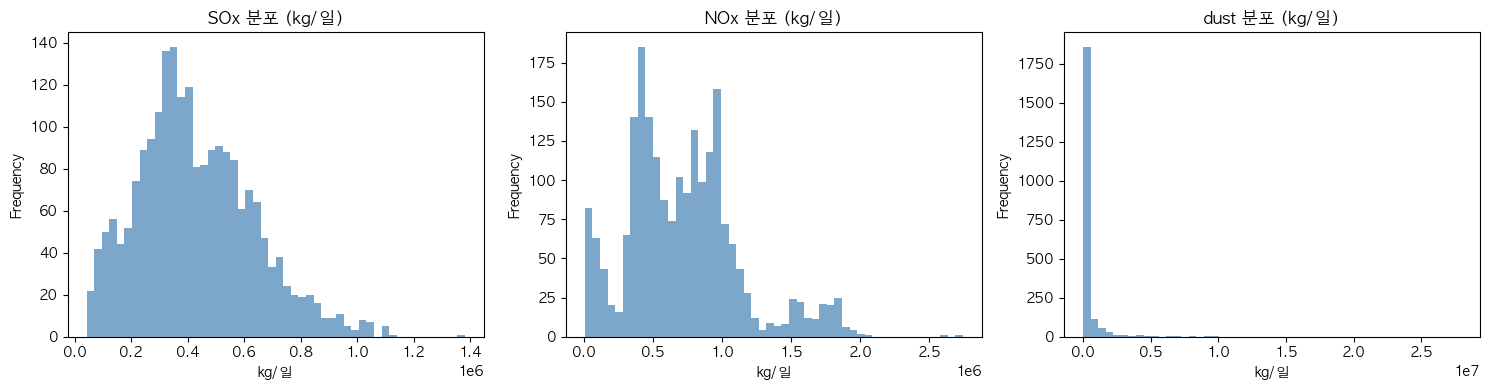

In [11]:
# 타겟 변수 분포 확인
target_cols = ['SOx', 'NOx', 'dust']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, target_cols):
    if col in master.columns:
        master[col].dropna().plot(kind='hist', bins=50, ax=ax, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} 분포 (kg/일)')
        ax.set_xlabel('kg/일')
plt.tight_layout()
plt.savefig('../reports/preprocessing_target_dist.png', dpi=150)
plt.show()

In [12]:
# 연도별 배출량 추이
master['year'] = master['date'].dt.year
yearly = master.groupby('year')[target_cols].mean().dropna()
print('연도별 평균 배출량 (kg/일):')
print(yearly.round(1).to_string())

연도별 평균 배출량 (kg/일):
           SOx        NOx      dust
year                               
2020  611960.9  1420713.1  198606.8
2021  461316.5   922244.4  263284.4
2022  387807.8   673254.0  367721.8
2023  408413.1   603861.0  429002.2
2024  394848.9   546157.2  476910.3
2025  405679.9   511966.3  291275.1
2026  423597.1   613297.6  971295.9


## 10. 저장

In [13]:
# 타겟 변수 컬럼명 통일 (features.py의 TARGET_COLS와 맞춤)
rename_map = {'SOx': 'SOx', 'NOx': 'NOx', 'dust': '먼지'}
master.rename(columns=rename_map, inplace=True)

# 연료 컬럼명 통일
if 'coal_ton' in master.columns:
    master.rename(columns={'coal_ton': '유연탄', 'lng_ton': 'LNG'}, inplace=True)

save_path = PROCESSED_DIR / 'master_dataset.csv'
master.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f'[OK] master_dataset.csv 저장: {save_path}')
print(f'     {len(master)} rows × {len(master.columns)} columns')
print(f'     컬럼: {master.columns.tolist()}')

[OK] master_dataset.csv 저장: ../data/processed/master_dataset.csv
     2123 rows × 36 columns
     컬럼: ['date', 'SOx', 'NOx', '먼지', 'SOx_conc', 'NOx_conc', 'dust_conc', 'n_units', 'temp_mean', 'humidity_mean', 'wind_dir', 'wind_speed_mean', 'precipitation', 'wind_sin', 'wind_cos', 'stagnation_idx', '유연탄', 'LNG', 'oil_ton', 'coal_ratio', 'lng_ratio', 'gen_mwh', 'heat_efficiency', 'utilization', 'api_gen_mwh', 'solar_mwh', 'wind_mwh', 'wind_speed_max', 'pressure_mean', 'solar_radiation', 'renewable_mwh', 'renewable_ratio', 'month', 'dayofweek', 'season', 'year']
